# Classificador Arousal-Valence: Q1-Q4 (Modelo Circumplexo de Russell)

**Autores:** Carlos Vitor Adorno Gomes e Eduardo Furtado de Simas Filho -- UFBA  
**Dataset:** DEAM (1802 faixas)

---
## Definição dos Quadrantes

| Quadrante | Arousal | Valence | Perfil emocional | N |
|-----------|---------|---------|------------------|---|
| **Q1** | Alto | Alta | Animado/Euforico | ~450 |
| **Q2** | Baixo | Alta | Calmo/Sereno | ~450 |
| **Q3** | Baixo | Baixa | Triste/Melancolico | ~450 |
| **Q4** | Alto | Baixa | Tenso/Raivoso | ~450 |

> **Particionamento:** medianas globais de arousal e valence (garantem ~450 amostras/classe).


## 1. Importações e Configuração do Ambiente


In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import signal
from scipy.stats import kruskal
import scikit_posthocs as sp
import seaborn as sns
import librosa
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    XGBClassifier = None
    HAS_XGBOOST = False

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)

warnings.filterwarnings('ignore')
np.random.seed(42)

try:
    display
except NameError:
    display = lambda x: print(x)

def salvar_tabela_como_imagem(df, caminho, titulo=None, fmt=None,
                              fontsize=10, header_color='#2c3e50', header_fontcolor='white',
                              row_colors=('#f5f6fa', '#ffffff')):
    df_show = df.to_frame() if isinstance(df, pd.Series) else df.copy()

    if fmt is not None:
        for c in df_show.columns:
            if pd.api.types.is_numeric_dtype(df_show[c]):
                df_show[c] = df_show[c].map(lambda v: fmt.format(v))

    col_labels = [str(c) for c in df_show.columns]
    row_labels = [str(i) for i in df_show.index]
    cell_text = df_show.astype(str).values

    n_rows, n_cols = df_show.shape

    col_char_widths = [
        max(len(col_labels[j]), max((len(cell_text[i][j]) for i in range(n_rows)), default=4))
        for j in range(n_cols)
    ]
    row_label_char_width = max((len(s) for s in row_labels), default=4)

    total_chars = row_label_char_width + sum(col_char_widths)
    col_widths = [w / total_chars for w in col_char_widths]

    fig_w = max(5.0, 0.16 * total_chars + 1.2)
    fig_h = max(1.2, 0.45 * (n_rows + 1))

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis('off')

    table = ax.table(cellText=cell_text, rowLabels=row_labels, colLabels=col_labels,
                      cellLoc='center', rowLoc='center', loc='center',
                      colWidths=col_widths)
    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, 1.6)

    for (r, c), cell in table.get_celld().items():
        cell.set_edgecolor('#d0d3d8')
        if r == 0 or c == -1:
            cell.set_facecolor(header_color)
            cell.set_text_props(color=header_fontcolor, fontweight='bold')
        else:
            cell.set_facecolor(row_colors[r % 2])

    if titulo:
        ax.set_title(titulo, fontsize=fontsize + 2, fontweight='bold', pad=10)

    fig.savefig(caminho, dpi=200, bbox_inches='tight', pad_inches=0.15)
    plt.show()
    print(f'Tabela salva em: {caminho}')

print('Imports OK - modulos de aprendizado de maquina expandidos.')
print('XGBoost disponivel:', HAS_XGBOOST)


Imports OK - modulos de aprendizado de maquina expandidos.
XGBoost disponivel: False


## 2. Caminhos dos Arquivos


In [2]:
# ATENCAO: ajuste estes 4 caminhos para o seu ambiente antes de executar.
# Os valores abaixo sao apenas exemplos (maquina original do autor) e
# provavelmente NAO existem no seu computador -- o notebook ira falhar
# com FileNotFoundError caso nao sejam corrigidos.
PATH_AROUSAL  = r"C:\Users\vitto\Desktop\PPGEEC\DEAM\annotations\annotations averaged per song\dynamic (per second annotations)\arousal.csv"    # CSV anotacoes arousal
PATH_VALENCE  = r"C:\Users\vitto\Desktop\PPGEEC\DEAM\annotations\annotations averaged per song\dynamic (per second annotations)\valence.csv"    # CSV anotacoes valence
PATH_AUDIO    = r"C:\Users\vitto\Desktop\PPGEEC\DEAM\Audio"                          # Pasta .mp3
PATH_FEATURES = r"C:\Users\vitto\Desktop\PPGEEC\features_extraidas.csv"              # CSV features pre-extraidas (gerado pela Secao 5 ou ja existente)
SAVE_FIGURES  = True
FIG_DIR       = "Images"
os.makedirs(FIG_DIR, exist_ok=True)
print('Caminhos configurados.')


Caminhos configurados.


## 3. Carregamento das Anotações e Particionamento Q1-Q4

Particionamento pelas **medianas globais** de arousal e valence, conforme o particionamento estatístico global.

- **Q1**: arousal >= mediana_a AND valence >= mediana_v -> Alto A / Alta V (Animado)
- **Q2**: arousal < mediana_a AND valence >= mediana_v -> Baixo A / Alta V (Calmo)
- **Q3**: arousal < mediana_a AND valence < mediana_v -> Baixo A / Baixa V (Triste)
- **Q4**: arousal >= mediana_a AND valence < mediana_v -> Alto A / Baixa V (Tenso)


In [3]:
df_arousal = pd.read_csv(PATH_AROUSAL)
df_valence = pd.read_csv(PATH_VALENCE)

# Media temporal por musica
arousal_mean = df_arousal.set_index('song_id').mean(axis=1).reset_index(name='arousal_mean')
valence_mean = df_valence.set_index('song_id').mean(axis=1).reset_index(name='valence_mean')
df_emotions  = pd.merge(arousal_mean, valence_mean, on='song_id')

# Medianas globais (ponto de corte)
mediana_a = df_emotions['arousal_mean'].median()
mediana_v = df_emotions['valence_mean'].median()
print(f'Mediana arousal : {mediana_a:.4f}')
print(f'Mediana valence : {mediana_v:.4f}')

def classify_quadrant(row):
    """Classifica nos quadrantes do modelo circumplexo de Russell."""
    high_a = row['arousal_mean'] >= mediana_a
    high_v = row['valence_mean'] >= mediana_v
    if high_a and high_v:       return 'Q1'  # Alto A / Alta V
    if not high_a and high_v:   return 'Q2'  # Baixo A / Alta V
    if not high_a and not high_v: return 'Q3' # Baixo A / Baixa V
    return 'Q4'                               # Alto A / Baixa V

df_emotions['quadrante'] = df_emotions.apply(classify_quadrant, axis=1)

print('\nDistribuicao dos quadrantes:')
print(df_emotions['quadrante'].value_counts().sort_index())
print(f'\nTotal: {len(df_emotions)} faixas')


Mediana arousal : 0.1571
Mediana valence : 0.1096

Distribuicao dos quadrantes:
quadrante
Q1    654
Q2    247
Q3    654
Q4    247
Name: count, dtype: int64

Total: 1802 faixas


### Espaço Arousal-Valence (Modelo Circumplexo de Russell)


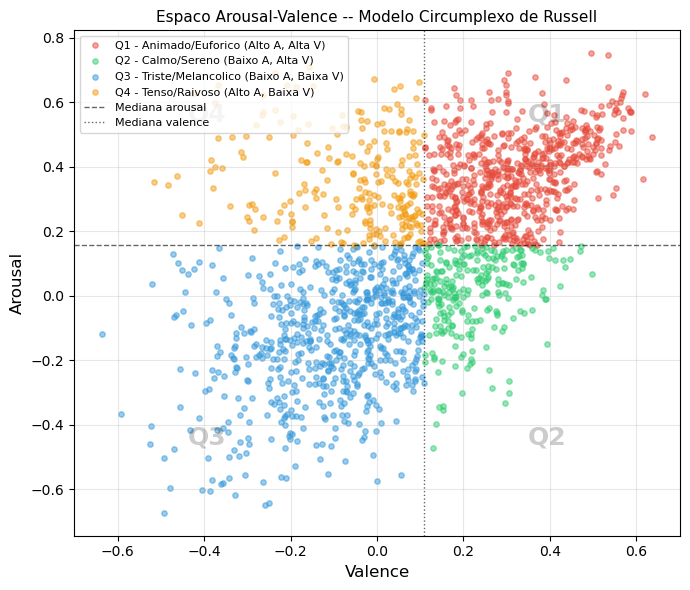

In [4]:
colors     = {'Q1':'#e74c3c', 'Q2':'#2ecc71', 'Q3':'#3498db', 'Q4':'#f39c12'}
labels_map = {
    'Q1': 'Q1 - Animado/Euforico (Alto A, Alta V)',
    'Q2': 'Q2 - Calmo/Sereno (Baixo A, Alta V)',
    'Q3': 'Q3 - Triste/Melancolico (Baixo A, Baixa V)',
    'Q4': 'Q4 - Tenso/Raivoso (Alto A, Baixa V)',
}
fig, ax = plt.subplots(figsize=(7, 6))
for q, grp in df_emotions.groupby('quadrante'):
    ax.scatter(grp['valence_mean'], grp['arousal_mean'],
               c=colors[q], label=labels_map[q], alpha=0.5, s=15)
ax.axhline(mediana_a, color='k', lw=1, ls='--', alpha=0.6, label='Mediana arousal')
ax.axvline(mediana_v, color='k', lw=1, ls=':',  alpha=0.6, label='Mediana valence')
for txt, xy in [('Q1',(0.78,0.82)),('Q2',(0.78,0.18)),
                ('Q3',(0.22,0.18)),('Q4',(0.22,0.82))]:
    ax.text(*xy, txt, transform=ax.transAxes, fontsize=18,
            fontweight='bold', alpha=0.2, ha='center')
ax.set_xlabel('Valence', fontsize=12)
ax.set_ylabel('Arousal', fontsize=12)
ax.set_title('Espaco Arousal-Valence -- Modelo Circumplexo de Russell', fontsize=11)
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
if SAVE_FIGURES: plt.savefig(f'{FIG_DIR}/circumplex_scatter.png', dpi=200, bbox_inches='tight')
plt.show()


In [5]:
# Contagem absoluta
contagem_quadrantes = df_emotions['quadrante'].value_counts().sort_index()

print("Quantidade de amostras por quadrante:")
print(contagem_quadrantes)

Quantidade de amostras por quadrante:
quadrante
Q1    654
Q2    247
Q3    654
Q4    247
Name: count, dtype: int64


## 4. Pré-processamento e Extração de Features Espectrais

### Janela de Ponderação de Hann
$$w[n] = 0{,}5\left(1 - \cos\left(\frac{2\pi n}{L-1}\right)\right), \quad 0 \le n \le L-1$$
com $L = 2048$ amostras $\approx 46{,}4$ ms a 44100 Hz.

### Transformada Discreta de Fourier (DFT) por Quadro
$$X_k[m] = \sum_{n=0}^{L-1} x_k[n]\,w[n]\,e^{-j2\pi mn/L}$$

### Densidade Espectral de Potência (PSD) Média de Welch
$$\overline{\mathrm{PSD}}[m] = \frac{1}{K}\sum_{k=1}^{K}\frac{1}{LU}|X_k[m]|^2, \quad U=\frac{1}{L}\sum_{n=0}^{L-1}|w[n]|^2$$

### Descritores Acústicos Espectrais
1. **Centroide espectral** : $C = \sum f[m]\overline{\mathrm{PSD}}[m] / \sum \overline{\mathrm{PSD}}[m]$
2. **Largura de banda** : $B = \sqrt{\sum (f[m]-C)^2\overline{\mathrm{PSD}}[m]/\sum\overline{\mathrm{PSD}}[m]}$
3. **Roll-off** $f_r$: frequencia abaixo da qual concentra 85% da energia (Secao 2.3)
4. **ZCR** : $\mathrm{ZCR} = \frac{1}{N-1}\sum \mathbb{I}\{\mathrm{sgn}(x[n])\neq\mathrm{sgn}(x[n-1])\}$
5. **Energia RMS**


In [6]:
SR      = 22050   # taxa de amostragem (Hz)
L       = 2048    # tamanho da janela -- ~46,4 ms a 44100 Hz 
HOP     = L // 2  # sobreposicao 50%
ROLLOFF = 0.85    # 85% da energia espectral (Secao 2.3)

def hann_window(L):
    """Janela de Ponderação de Hann."""
    n = np.arange(L)
    return 0.5 * (1.0 - np.cos(2.0 * np.pi * n / (L - 1)))

def compute_welch_psd(x, sr, L=L):
    """PSD média obtida pelo método de Welch com janela de Hann."""
    w = hann_window(L)
    f_arr, Pxx = signal.welch(x, fs=sr, window=w, nperseg=L,
                              noverlap=L // 2, scaling='density')
    return f_arr, Pxx

def extract_features(x, sr, L=L):
    """
    Extrai os 5 descritores espectrais/energeticos .
    Retorna dict: spectral_centroid, spectral_bandwidth,
                  spectral_rolloff, zcr, rms_energy
    """
    # Normalizacao RMS 
    rms_global = np.sqrt(np.mean(x ** 2)) + 1e-12
    x_norm = x / rms_global

    f_arr, Pxx = compute_welch_psd(x_norm, sr, L)
    eps = 1e-20

    # Centroide espectral
    centroid  = np.sum(f_arr * Pxx) / (np.sum(Pxx) + eps)

    # Largura de banda espectral
    bandwidth = np.sqrt(np.sum((f_arr - centroid) ** 2 * Pxx) /
                        (np.sum(Pxx) + eps))

    # Roll-off 85% -- Secao 2.3
    cumE        = np.cumsum(Pxx)
    idx_r       = np.searchsorted(cumE, ROLLOFF * cumE[-1])
    rolloff_hz  = f_arr[min(idx_r, len(f_arr) - 1)]

    # Taxa de cruzamentos por zero (ZCR)
    zcr = float(np.mean(librosa.feature.zero_crossing_rate(
        x_norm, frame_length=L, hop_length=HOP)))

    # Energia RMS
    rms_energy = float(np.mean(librosa.feature.rms(
        y=x_norm, frame_length=L, hop_length=HOP)))

    return dict(spectral_centroid=centroid,
                spectral_bandwidth=bandwidth,
                spectral_rolloff=rolloff_hz,
                zcr=zcr,
                rms_energy=rms_energy)

print(f'Funcoes definidas. L={L}, hop={HOP}, roll-off={int(ROLLOFF*100)}%')


Funcoes definidas. L=2048, hop=1024, roll-off=85%


## 5. Extração de Features das Músicas do DEAM

> Itera sobre os arquivos `.mp3`, aplica pre-processamento e extrai os 5 descritores.  
> **Se voce ja possui o CSV**, pule para o bloco alternativo abaixo.


In [7]:
audio_files = sorted([f for f in os.listdir(PATH_AUDIO) if f.endswith('.mp3')])
print(f'{len(audio_files)} arquivos .mp3 encontrados.')

valid_ids = set(df_emotions['song_id'].values)
records   = []

for fname in tqdm(audio_files, desc='Extraindo features'):
    try:
        song_id = int(os.path.splitext(fname)[0])
        if song_id not in valid_ids:
            continue
        y, sr = librosa.load(os.path.join(PATH_AUDIO, fname), sr=SR, mono=True)
        feats = extract_features(y, sr)
        feats['song_id'] = song_id
        records.append(feats)
    except Exception as e:
        print(f'  ERRO em {fname}: {e}')

df_features = pd.DataFrame(records)
df_features.to_csv('features_extraidas.csv', index=False)
print(f'{len(df_features)} faixas processadas. Salvo em features_extraidas.csv')


1802 arquivos .mp3 encontrados.


Extraindo features:   0%|          | 0/1802 [00:00<?, ?it/s]

1802 faixas processadas. Salvo em features_extraidas.csv


### Alternativa: carregar CSV de features pre-extraidas


In [8]:
# Execute ESTE bloco se ja tem o CSV:
df_features = pd.read_csv(PATH_FEATURES)
print(df_features.shape, df_features.head())


(1802, 6)    spectral_centroid  spectral_bandwidth  spectral_rolloff       zcr  \
0         719.216978          876.744119       1539.624023  0.076007   
1         614.150834         1141.766004       1162.792969  0.092013   
2         780.221208          883.815771       1431.958008  0.094548   
3         451.615565          608.712208        818.261719  0.041187   
4         745.582949          994.340121       1012.060547  0.070217   

   rms_energy  song_id  
0    0.895682       10  
1    0.969071     1000  
2    0.941737     1001  
3    0.738523     1002  
4    0.707342     1003  


## 6. Construção do Dataset Final


Dataset final:
quadrante
Q1    654
Q2    247
Q3    654
Q4    247
Name: count, dtype: int64
Total: 1802 amostras  |  Features: ['spectral_centroid', 'spectral_bandwidth', 'spectral_rolloff', 'zcr', 'rms_energy']


,spectral_centroid,spectral_bandwidth,spectral_rolloff,zcr,rms_energy
count,1802.0000,1802.0000,1802.0000,1802.0000,1802.0000
mean,574.2045,863.3584,959.3807,0.0798,0.9193
std,303.9612,420.2932,722.0993,0.0361,0.0637
min,76.6305,60.5134,64.5996,0.0138,0.5504
25%,368.9766,562.1145,484.4971,0.0534,0.8900
50%,516.1322,816.0911,775.1953,0.0740,0.9368
75%,698.1456,1109.4233,1227.3926,0.0996,0.9648
max,2497.0936,3116.6405,8150.3174,0.3476,0.9973


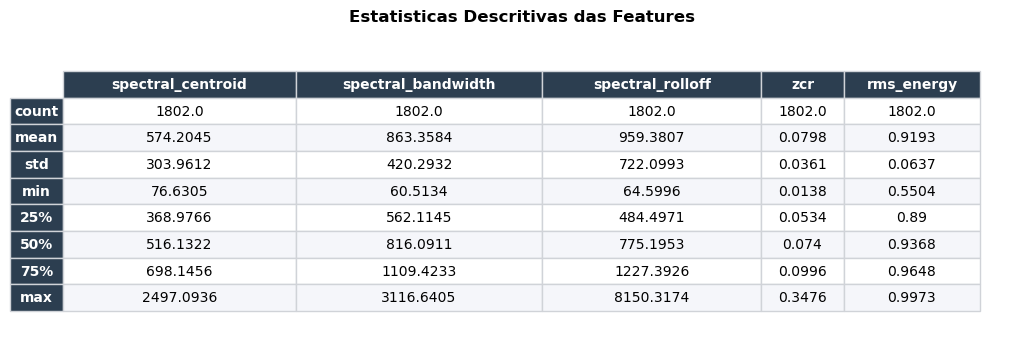

Tabela salva em: Images/tabela_describe_features.png


In [9]:
FEATURES = ['spectral_centroid', 'spectral_bandwidth',
            'spectral_rolloff', 'zcr', 'rms_energy']

dataset = pd.merge(
    df_features[['song_id'] + FEATURES],
    df_emotions[['song_id', 'arousal_mean', 'valence_mean', 'quadrante']],
    on='song_id'
).dropna()

# Grupos por quadrante
QUAD_ORDER = ['Q1', 'Q2', 'Q3', 'Q4']
groups = {q: dataset[dataset['quadrante'] == q] for q in QUAD_ORDER}

print('Dataset final:')
print(dataset['quadrante'].value_counts().sort_index())
print(f'Total: {len(dataset)} amostras  |  Features: {FEATURES}')

describe_table = dataset[FEATURES].describe().round(4)
display(describe_table)

if SAVE_FIGURES:
    salvar_tabela_como_imagem(
        describe_table, f'{FIG_DIR}/tabela_describe_features.png',
        titulo='Estatisticas Descritivas das Features'
    )


## 7. Análise Estatística: Teste de Kruskal-Wallis

Teste nao-parametrico para multiplos grupos -- extensao do Mann-Whitney.  
O teste estatístico confirma elevadíssima significância (p < 10^{-30}) para todos os descritores espectrais.

### Tamanho de Efeito (Eta-quadrado - $\eta^2$)
$$\eta^2 = \frac{H - (k-1)}{n - k}$$
com $k=4$, $n$ = total de amostras. Resultados esperados: centroide eta2=0,42; roll-off eta2=0,40.


Feature                            H        p-value     eta2
--------------------------------------------------------------
spectral_centroid             149.45       3.46e-32   0.0815
spectral_bandwidth            601.64      4.44e-130   0.3329
spectral_rolloff              112.09       3.89e-24   0.0607
zcr                           465.54      1.40e-100   0.2573
rms_energy                    264.61       4.52e-57   0.1455


,H,p-value,eta2
Feature,,,
spectral_centroid,149.45,3.46e-32,0.0815
spectral_bandwidth,601.64,4.44e-130,0.3329
spectral_rolloff,112.09,3.89e-24,0.0607
zcr,465.54,1.40e-100,0.2573
rms_energy,264.61,4.52e-57,0.1455


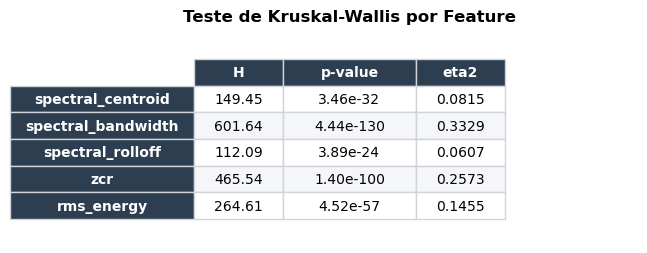

Tabela salva em: Images/tabela_kruskal_wallis.png


In [10]:
n_total = len(dataset)
k_groups = 4

print(f"{'Feature':<25} {'H':>10} {'p-value':>14} {'eta2':>8}")
print('-' * 62)

kw_results = {}
rows_kw = []
for feat in FEATURES:
    samples = [groups[q][feat].values for q in QUAD_ORDER]
    H, p    = kruskal(*samples)
    eta2    = max((H - (k_groups - 1)) / (n_total - k_groups), 0)  
    kw_results[feat] = {'H': H, 'p': p, 'eta2': eta2}
    print(f"{feat:<25} {H:>10.2f} {p:>14.2e} {eta2:>8.4f}")
    rows_kw.append({'Feature': feat, 'H': round(H, 2), 'p-value': f'{p:.2e}', 'eta2': round(eta2, 4)})

kw_table = pd.DataFrame(rows_kw).set_index('Feature')
display(kw_table)

if SAVE_FIGURES:
    salvar_tabela_como_imagem(
        kw_table, f'{FIG_DIR}/tabela_kruskal_wallis.png',
        titulo='Teste de Kruskal-Wallis por Feature'
    )


### Post-hoc de Dunn com Correcao de Bonferroni

Identifica quais pares de quadrantes diferem significativamente.  
A análise indica que comparações no eixo de *arousal* (Q1 vs Q4, Q2 vs Q3)
produzem p-valores menores que as comparacoes diagonais.


p-valores post-hoc de Dunn (Bonferroni) -- spectral_centroid:


,Q1,Q2,Q3,Q4
Q1,1.000,0.0,0.0,0.959
Q2,0.000,1.0,1.0,0.000
Q3,0.000,1.0,1.0,0.000
Q4,0.959,0.0,0.0,1.000


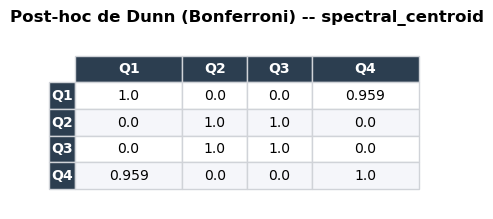

Tabela salva em: Images/tabela_dunn_posthoc.png


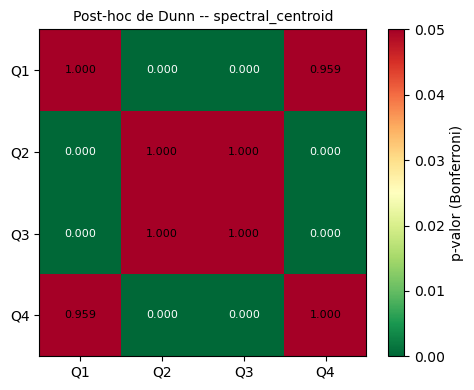

In [11]:
feat_highlight = 'spectral_centroid'   # feature de maior eta2

data_dunn = dataset[['quadrante', feat_highlight]].rename(
    columns={'quadrante': 'group', feat_highlight: 'value'})

pvals_dunn = sp.posthoc_dunn(
    data_dunn, val_col='value', group_col='group', p_adjust='bonferroni'
)
print(f'p-valores post-hoc de Dunn (Bonferroni) -- {feat_highlight}:')
pvals_dunn_round = pvals_dunn.round(4)
display(pvals_dunn_round)

if SAVE_FIGURES:
    salvar_tabela_como_imagem(
        pvals_dunn_round, f'{FIG_DIR}/tabela_dunn_posthoc.png',
        titulo=f'Post-hoc de Dunn (Bonferroni) -- {feat_highlight}'
    )

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(pvals_dunn.values, cmap='RdYlGn_r', vmin=0, vmax=0.05)
qs = pvals_dunn.columns.tolist()
ax.set_xticks(range(len(qs))); ax.set_xticklabels(qs)
ax.set_yticks(range(len(qs))); ax.set_yticklabels(qs)
plt.colorbar(im, ax=ax, label='p-valor (Bonferroni)')
ax.set_title(f'Post-hoc de Dunn -- {feat_highlight}', fontsize=10)
for i in range(len(qs)):
    for j in range(len(qs)):
        v = pvals_dunn.values[i, j]
        ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=8,
                color='white' if v < 0.025 else 'black')
plt.tight_layout()
if SAVE_FIGURES: plt.savefig(f'{FIG_DIR}/dunn_posthoc.png', dpi=200, bbox_inches='tight')
plt.show()


## 8. Histogramas das Features por Quadrante

> *Histogramas das features por quadrante (Q1-Q4), evidenciando o escalonamento dos*
> *descritores espectrais ao longo dos eixos de arousal e valence.*


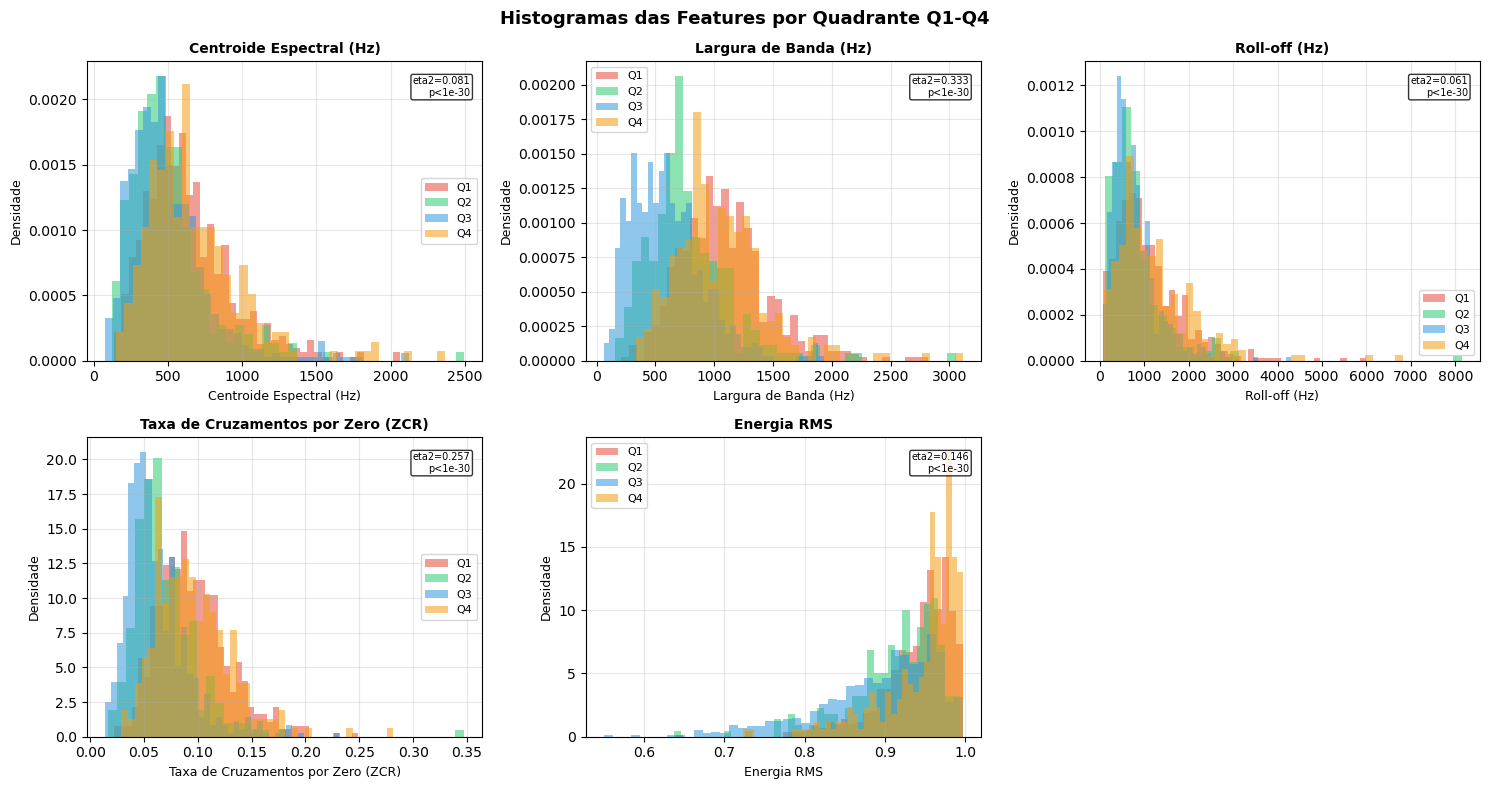

In [12]:
feat_labels = {
    'spectral_centroid'  : 'Centroide Espectral (Hz)',
    'spectral_bandwidth' : 'Largura de Banda (Hz)',
    'spectral_rolloff'   : 'Roll-off (Hz)',
    'zcr'                : 'Taxa de Cruzamentos por Zero (ZCR)',
    'rms_energy'         : 'Energia RMS',
}
quad_colors = {'Q1':'#e74c3c', 'Q2':'#2ecc71', 'Q3':'#3498db', 'Q4':'#f39c12'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    for q in QUAD_ORDER:
        ax.hist(groups[q][feat].values, bins=40, alpha=0.55,
                color=quad_colors[q], label=q, density=True, edgecolor='none')
    ax.set_xlabel(feat_labels[feat], fontsize=9)
    ax.set_ylabel('Densidade', fontsize=9)
    ax.set_title(feat_labels[feat], fontsize=10, fontweight='bold')
    eta2_v = kw_results[feat]['eta2']
    ax.text(0.97, 0.95, f'eta2={eta2_v:.3f}\np<1e-30',
            transform=ax.transAxes, ha='right', va='top', fontsize=7,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.delaxes(axes[-1])
plt.suptitle('Histogramas das Features por Quadrante Q1-Q4', fontsize=13, fontweight='bold')
plt.tight_layout()
if SAVE_FIGURES: plt.savefig(f'{FIG_DIR}/histogramas.png', dpi=200, bbox_inches='tight')
plt.show()


### Boxplots por Quadrante


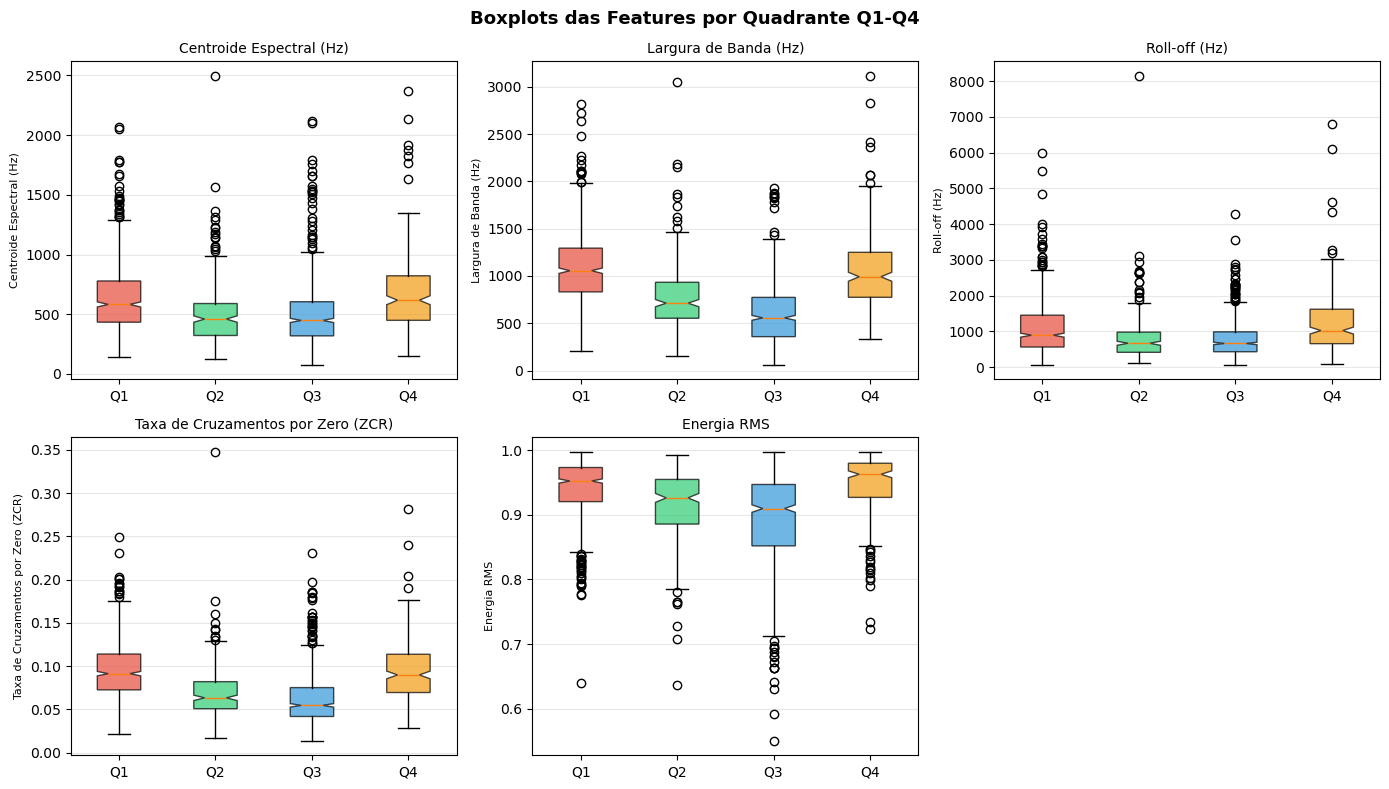

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    data_bp = [groups[q][feat].values for q in QUAD_ORDER]
    bp = ax.boxplot(data_bp, labels=QUAD_ORDER, patch_artist=True, notch=True)
    for patch, q in zip(bp['boxes'], QUAD_ORDER):
        patch.set_facecolor(quad_colors[q])
        patch.set_alpha(0.7)
    ax.set_title(feat_labels[feat], fontsize=10)
    ax.set_ylabel(feat_labels[feat], fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

fig.delaxes(axes[-1])
plt.suptitle('Boxplots das Features por Quadrante Q1-Q4', fontsize=13, fontweight='bold')
plt.tight_layout()
if SAVE_FIGURES: plt.savefig(f'{FIG_DIR}/boxplots.png', dpi=200, bbox_inches='tight')
plt.show()


## 8.5. Visualização do Espaço de Características

> *Projeção bidimensional das features utilizando PCA para visualizar a separabilidade das classes.*

PC1 explica 86.71% da variancia
PC2 explica 11.82% da variancia
Variancia acumulada (PC1 + PC2): 98.53%


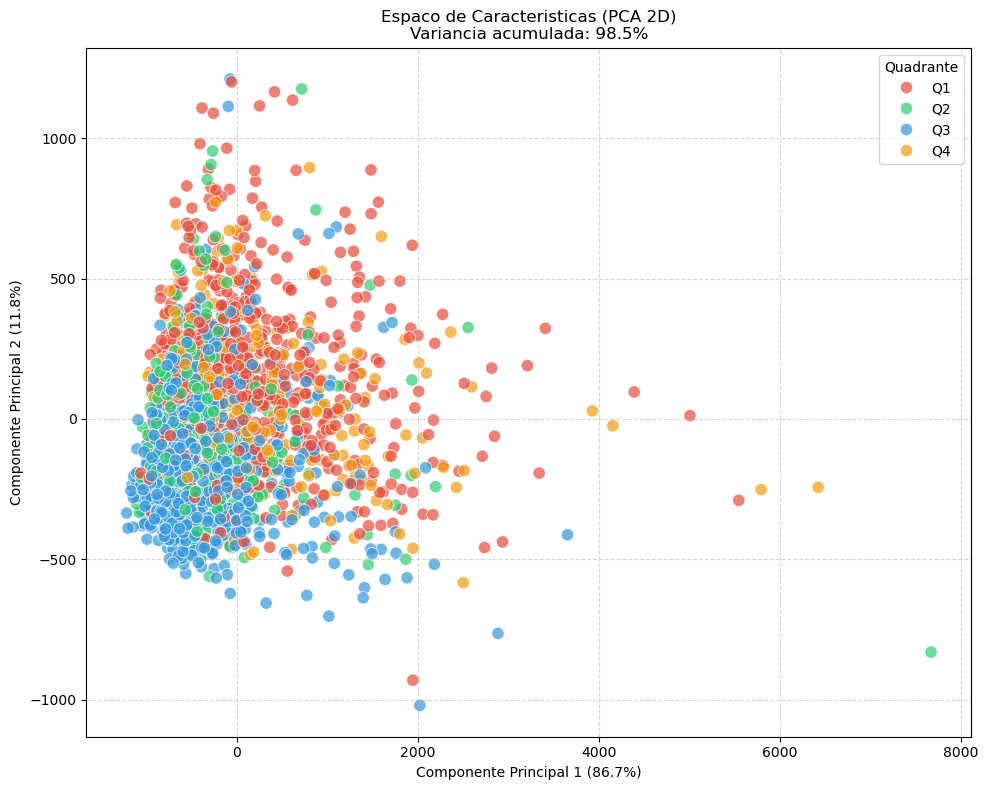

Imagem 'Images/pca_espaco_caracteristicas.png' e arquivo 'Images/resultados_espaco_caracteristicas.txt' gerados com sucesso!


In [14]:
# PCA para 2 componentes principais
pca = PCA(n_components=2)
X_pca = pca.fit_transform(dataset[FEATURES].values)
y_labels = dataset['quadrante'].values

# Variancia explicada
var_exp = pca.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

print(f"PC1 explica {var_exp[0]*100:.2f}% da variancia")
print(f"PC2 explica {var_exp[1]*100:.2f}% da variancia")
print(f"Variancia acumulada (PC1 + PC2): {var_acum[1]*100:.2f}%")

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=y_labels,
    palette=colors,
    s=80,
    alpha=0.7,
    hue_order=QUAD_ORDER
)

plt.title(
    f'Espaco de Caracteristicas (PCA 2D)\n'
    f'Variancia acumulada: {var_acum[1]*100:.1f}%'
)

plt.xlabel(f'Componente Principal 1 ({var_exp[0]*100:.1f}%)')
plt.ylabel(f'Componente Principal 2 ({var_exp[1]*100:.1f}%)')
plt.legend(title='Quadrante')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Salvar a imagem (mesma pasta das demais figuras, FIG_DIR)
img_filename = 'pca_espaco_caracteristicas.png'
img_path = f'{FIG_DIR}/{img_filename}'
if SAVE_FIGURES:
    plt.savefig(img_path, dpi=200, bbox_inches='tight')
plt.show()

# Gerar arquivo .txt com a secao em LaTeX
latex_content = rf"""
\section{{Visualizacao do Espaco de Caracteristicas}}

"""

txt_path = f'{FIG_DIR}/resultados_espaco_caracteristicas.txt'
with open(txt_path, 'w', encoding='utf-8') as f:
    f.write(latex_content)

print(f"Imagem '{img_path}' e arquivo '{txt_path}' gerados com sucesso!")


## 9. PSD Média por Quadrante (Método de Welch)

> *PSD media (metodo de Welch) por quadrante Q1-Q4, evidenciando maior potencia espectral*
> *nos grupos de alto arousal (Q1 e Q4).*

Cálculo do espectro via janela de Hann (L=2048, sobreposição 50%).


Calculando PSD:   0%|          | 0/1802 [00:00<?, ?it/s]

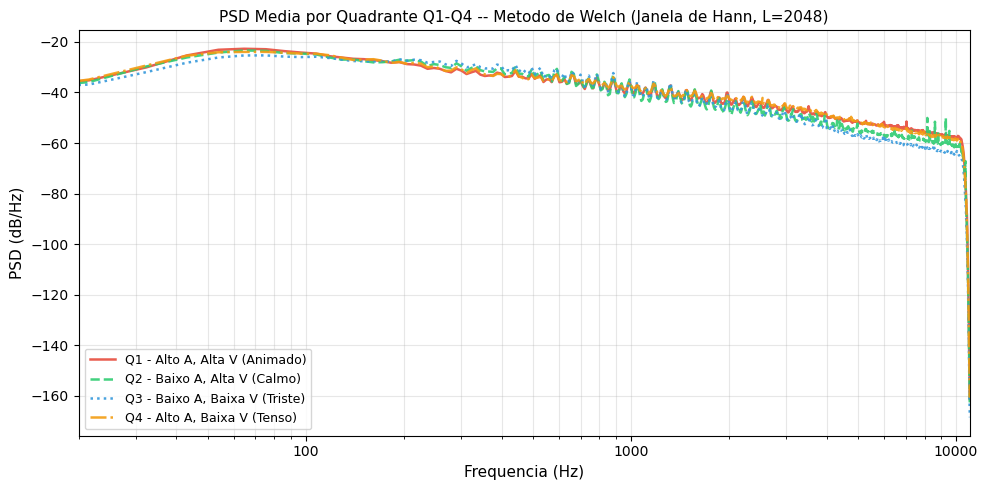

In [15]:
psd_by_quad  = {q: [] for q in QUAD_ORDER}
ids_by_quad  = {q: set(groups[q]['song_id'].values) for q in QUAD_ORDER}
audio_files  = sorted([f for f in os.listdir(PATH_AUDIO) if f.endswith('.mp3')])

f_ref = None
for fname in tqdm(audio_files, desc='Calculando PSD'):
    try:
        song_id = int(os.path.splitext(fname)[0])
        q_label = next((q for q in QUAD_ORDER if song_id in ids_by_quad[q]), None)
        if q_label is None:
            continue
        y, sr = librosa.load(os.path.join(PATH_AUDIO, fname), sr=SR, mono=True)
        rms = np.sqrt(np.mean(y**2)) + 1e-12
        f_arr, Pxx = compute_welch_psd(y / rms, sr)
        psd_by_quad[q_label].append(Pxx)
        if f_ref is None:
            f_ref = f_arr
    except Exception:
        pass

# Plot PSD media
psd_styles = {
    'Q1': ('Q1 - Alto A, Alta V (Animado)',  '#e74c3c', '-'),
    'Q2': ('Q2 - Baixo A, Alta V (Calmo)',   '#2ecc71', '--'),
    'Q3': ('Q3 - Baixo A, Baixa V (Triste)', '#3498db', ':'),
    'Q4': ('Q4 - Alto A, Baixa V (Tenso)',   '#f39c12', '-.'),
}

fig, ax = plt.subplots(figsize=(10, 5))
for q in QUAD_ORDER:
    if psd_by_quad[q] and f_ref is not None:
        mean_psd = np.mean(psd_by_quad[q], axis=0)
        lbl, clr, ls = psd_styles[q]
        ax.plot(f_ref, 10 * np.log10(mean_psd + 1e-20),
                label=lbl, color=clr, ls=ls, lw=1.8, alpha=0.9)

ax.set_xlabel('Frequencia (Hz)', fontsize=11)
ax.set_ylabel('PSD (dB/Hz)', fontsize=11)
ax.set_title('PSD Media por Quadrante Q1-Q4 -- Metodo de Welch (Janela de Hann, L=2048)', fontsize=11)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xlim([20, SR // 2])
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
if SAVE_FIGURES: plt.savefig(f'{FIG_DIR}/PSD.png', dpi=200, bbox_inches='tight')
plt.show()


## 10. Análise da Relevância e Seleção de Atributos (Feature Selection)

Nesta secao, a relevancia dos descritores e tratada em dois niveis:
1. **Análise explicativa**: ranking por tamanho de efeito no Kruskal-Wallis e importancia media por Random Forest.
2. **Avaliação preditiva sem vazamento de informacao**: a seleção dos melhores atributos e executada dentro de cada fold de validacao cruzada por `SelectKBest(f_classif)`, evitando escolher atributos com acesso aos dados de teste.
3. **Comparação direta**: todos os classificadores sao avaliados com o vetor completo de 5 descritores e com seleção supervisionada de atributos, permitindo verificar se a análise de atributos converge para um sistema de classificacao melhor.


=== RANKING EXPLICATIVO DE RELEVANCIA DOS ATRIBUTOS ===


,Feature,eta2_Kruskal,H_stat,p_value,RF_Gini_Importance_Mean,RF_Gini_Importance_Std
0,spectral_bandwidth,0.332949,601.642807,4.438681e-130,0.261728,0.002885
1,zcr,0.257252,465.538662,1.400915e-100,0.216096,0.002056
2,rms_energy,0.145500,264.609747,4.524792e-57,0.202727,0.001825
3,spectral_centroid,0.081451,149.449595,3.463360e-32,0.170119,0.001795
4,spectral_rolloff,0.060675,112.093547,3.888211e-24,0.149330,0.001067



Top-3 exploratorio por eta2: ['spectral_bandwidth', 'zcr', 'rms_energy']
Observacao metodologica: a avaliacao preditiva usa SelectKBest dentro do pipeline de CV, nao esta lista fixa.


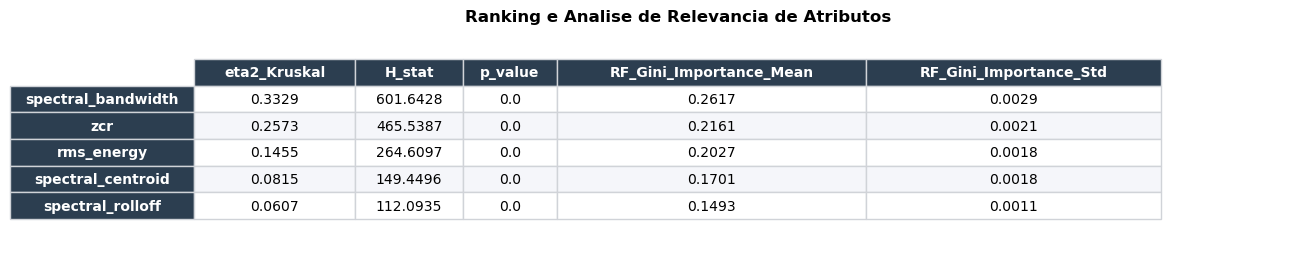

Tabela salva em: Images/tabela_ranking_atributos.png


In [16]:
# 10.1 Ranking explicativo de atributos
le_global = LabelEncoder()
y_quad_global = le_global.fit_transform(dataset['quadrante'])

rf_importances = []
rf_importance_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, _ in rf_importance_folds.split(dataset[FEATURES].values, y_quad_global):
    rf_eval = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    rf_eval.fit(dataset.iloc[train_idx][FEATURES].values, y_quad_global[train_idx])
    rf_importances.append(rf_eval.feature_importances_)

rf_importances = np.asarray(rf_importances)
df_feat_eval = pd.DataFrame({
    'Feature': FEATURES,
    'eta2_Kruskal': [kw_results[f]['eta2'] for f in FEATURES],
    'H_stat': [kw_results[f]['H'] for f in FEATURES],
    'p_value': [kw_results[f]['p'] for f in FEATURES],
    'RF_Gini_Importance_Mean': rf_importances.mean(axis=0),
    'RF_Gini_Importance_Std': rf_importances.std(axis=0)
}).sort_values(by=['eta2_Kruskal', 'RF_Gini_Importance_Mean'], ascending=False).reset_index(drop=True)

FEATURES_SELECTED_EXPLORATORY = df_feat_eval.iloc[:3]['Feature'].tolist()
print('=== RANKING EXPLICATIVO DE RELEVANCIA DOS ATRIBUTOS ===')
display(df_feat_eval)
print(f"\nTop-3 exploratorio por eta2: {FEATURES_SELECTED_EXPLORATORY}")
print('Observacao metodologica: a avaliacao preditiva usa SelectKBest dentro do pipeline de CV, nao esta lista fixa.')

if SAVE_FIGURES:
    salvar_tabela_como_imagem(
        df_feat_eval.set_index('Feature').round(4),
        f'{FIG_DIR}/tabela_ranking_atributos.png',
        titulo='Ranking e Analise de Relevancia de Atributos'
    )


## 11. Abordagem Multiclasse Direta (4 Quadrantes Q1-Q4) e Comparação de Classificadores

### Métodologia de treinamento e hiperparametros
1. **Baseline majoritario (`DummyClassifier`)**: referencia minima, projetada para prever sempre a classe mais frequente.
2. **Random Forest**: ensemble por bagging de arvores de decisao. Hiperparametros investigados: numero de arvores, profundidade maxima, divisao minima e folhas minimas.
3. **XGBoost ou Gradient Boosting**: quando `xgboost` esta instalado, usa-se `XGBClassifier`; caso contrario, usa-se `GradientBoostingClassifier` como ensemble de boosting baseado em arvores.
4. **SVM**: modelo de margem maxima com padronizacao dos atributos dentro do pipeline.
5. **MLP**: rede neural feed-forward com padronizacao dos atributos dentro do pipeline.

A avaliacao usa **validacao cruzada estratificada externa com 5 folds**. Dentro de cada fold externo, a escolha de hiperparametros ocorre somente no conjunto de treino por `GridSearchCV` com 3 folds internos. Assim, os resultados reportados refletem desempenho fora da amostra e respondem diretamente a critica sobre comparação metodologica entre classificadores.


In [17]:
# 11.1 Definicao dos pipelines e espacos de hiperparametros

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
RUN_FULL_GRID = False  # altere para True para uma busca mais ampla nos resultados finais

X = dataset[FEATURES].values
le = LabelEncoder()
y_quad = le.fit_transform(dataset['quadrante'])
class_names = le.classes_
y_arousal = (dataset['arousal_mean'] >= mediana_a).astype(int).values
y_valence = (dataset['valence_mean'] >= mediana_v).astype(int).values

xgb_or_gb_name = 'XGBoost' if HAS_XGBOOST else 'Gradient Boosting'
if HAS_XGBOOST:
    xgb_or_gb_model = XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1)
    xgb_or_gb_params = {
        'clf__n_estimators': ([100, 150] if RUN_FULL_GRID else [100]),
        'clf__learning_rate': ([0.05, 0.1] if RUN_FULL_GRID else [0.1]),
        'clf__max_depth': ([3, 5] if RUN_FULL_GRID else [3])
    }
else:
    xgb_or_gb_model = GradientBoostingClassifier(random_state=42)
    xgb_or_gb_params = {
        'clf__n_estimators': ([100, 150] if RUN_FULL_GRID else [100]),
        'clf__learning_rate': ([0.05, 0.1] if RUN_FULL_GRID else [0.1]),
        'clf__max_depth': ([3, 5] if RUN_FULL_GRID else [3])
    }

model_specs = {
    'Majoritario (Baseline)': {
        'estimator': DummyClassifier(strategy='most_frequent'),
        'params': {}
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {
            'clf__n_estimators': ([100, 200] if RUN_FULL_GRID else [100]),
            'clf__max_depth': ([None, 10] if RUN_FULL_GRID else [10]),
            'clf__min_samples_split': ([2, 5] if RUN_FULL_GRID else [2]),
            'clf__min_samples_leaf': ([1, 2] if RUN_FULL_GRID else [1])
        }
    },
    xgb_or_gb_name: {
        'estimator': xgb_or_gb_model,
        'params': xgb_or_gb_params
    },
    'SVM (RBF/Linear)': {
        'estimator': SVC(random_state=42),
        'params': {
            'clf__C': ([0.1, 1, 10] if RUN_FULL_GRID else [1, 10]),
            'clf__kernel': (['rbf', 'linear'] if RUN_FULL_GRID else ['rbf']),
            'clf__gamma': (['scale', 'auto'] if RUN_FULL_GRID else ['scale'])
        },
        'scale': True
    },
    'MLP (Rede Neural)': {
        'estimator': MLPClassifier(max_iter=1000, early_stopping=True, random_state=42),
        'params': {
            'clf__hidden_layer_sizes': ([(50,), (100,), (50, 25)] if RUN_FULL_GRID else [(50,), (50, 25)]),
            'clf__alpha': ([0.0001, 0.001, 0.01] if RUN_FULL_GRID else [0.001]),
            'clf__activation': (['relu', 'tanh'] if RUN_FULL_GRID else ['relu'])
        },
        'scale': True
    }
}

def build_pipeline(spec, feature_mode='all'):
    steps = []
    if feature_mode == 'select_k_best':
        steps.append(('select', SelectKBest(score_func=f_classif, k=3)))
    if spec.get('scale', False):
        steps.append(('scaler', StandardScaler()))
    steps.append(('clf', clone(spec['estimator'])))
    return Pipeline(steps)

def params_for_mode(spec, feature_mode='all'):
    params = dict(spec['params'])
    if feature_mode == 'select_k_best':
        params['select__k'] = ([2, 3, 4] if RUN_FULL_GRID else [3])
    return params

feature_modes = {
    'Todas (5 Features)': 'all',
    'Selecao supervisionada CV': 'select_k_best'
}

print('Configuracao de validacao aninhada definida.')
print('RUN_FULL_GRID:', RUN_FULL_GRID)
print('Modelos avaliados:', list(model_specs.keys()))


Configuracao de validacao aninhada definida.
RUN_FULL_GRID: False
Modelos avaliados: ['Majoritario (Baseline)', 'Random Forest', 'Gradient Boosting', 'SVM (RBF/Linear)', 'MLP (Rede Neural)']


In [18]:
# 11.2 Execucao do treinamento e avaliacao multiclasse com CV aninhada

def summarize_scores(values, scale=1.0):
    values = np.asarray(values) * scale
    return values.mean(), values.std(ddof=0)

def evaluate_nested_multiclass(X_data, y_data):
    rows = []
    fitted_models = {}
    oof_predictions = {}

    for feat_label, feature_mode in feature_modes.items():
        print(f"\n================ MULTICLASSE DIRETA: {feat_label} ================")
        for model_name, spec in model_specs.items():
            fold_metrics = {'accuracy': [], 'f1_macro': [], 'precision_macro': [], 'recall_macro': []}
            fold_params = []
            y_pred_all = np.empty_like(y_data)

            for fold_id, (train_idx, test_idx) in enumerate(outer_cv.split(X_data, y_data), start=1):
                pipe = build_pipeline(spec, feature_mode)
                params = params_for_mode(spec, feature_mode)

                if params:
                    search = GridSearchCV(
                        pipe, params, cv=inner_cv, scoring='f1_macro',
                        n_jobs=-1, refit=True, error_score='raise'
                    )
                    search.fit(X_data[train_idx], y_data[train_idx])
                    fitted = search.best_estimator_
                    fold_params.append(search.best_params_)
                else:
                    fitted = pipe.fit(X_data[train_idx], y_data[train_idx])
                    fold_params.append({'strategy': 'most_frequent'})

                pred = fitted.predict(X_data[test_idx])
                y_pred_all[test_idx] = pred
                fold_metrics['accuracy'].append(accuracy_score(y_data[test_idx], pred))
                fold_metrics['f1_macro'].append(f1_score(y_data[test_idx], pred, average='macro', zero_division=0))
                fold_metrics['precision_macro'].append(precision_score(y_data[test_idx], pred, average='macro', zero_division=0))
                fold_metrics['recall_macro'].append(recall_score(y_data[test_idx], pred, average='macro', zero_division=0))
                print(f'{model_name} | fold {fold_id}: acc={fold_metrics["accuracy"][-1]*100:.1f}% f1={fold_metrics["f1_macro"][-1]:.3f}')

            acc_m, acc_s = summarize_scores(fold_metrics['accuracy'], 100)
            f1_m, f1_s = summarize_scores(fold_metrics['f1_macro'])
            p_m, p_s = summarize_scores(fold_metrics['precision_macro'])
            r_m, r_s = summarize_scores(fold_metrics['recall_macro'])

            final_pipe = build_pipeline(spec, feature_mode)
            final_params = params_for_mode(spec, feature_mode)
            if final_params:
                final_search = GridSearchCV(final_pipe, final_params, cv=inner_cv, scoring='f1_macro', n_jobs=-1, refit=True)
                final_search.fit(X_data, y_data)
                fitted_models[(model_name, feat_label)] = final_search.best_estimator_
                final_best_params = final_search.best_params_
            else:
                fitted_models[(model_name, feat_label)] = final_pipe.fit(X_data, y_data)
                final_best_params = {'strategy': 'most_frequent'}

            rows.append({
                'Modelo': model_name,
                'Abordagem': 'Multiclasse Direta (4Q)',
                'Atributos': feat_label,
                'Acuracia (%)': f'{acc_m:.1f} +/- {acc_s:.1f}',
                'F1-Macro': f'{f1_m:.3f} +/- {f1_s:.3f}',
                'Precisao': f'{p_m:.3f} +/- {p_s:.3f}',
                'Recall': f'{r_m:.3f} +/- {r_s:.3f}',
                'Acc_raw': acc_m,
                'F1_raw': f1_m,
                'Best_Params_Final': str(final_best_params),
                'Params_por_fold': str(fold_params)
            })
            oof_predictions[(model_name, feat_label)] = y_pred_all
            print(f'[{model_name}] {feat_label}: Acc={acc_m:.1f}% +/- {acc_s:.1f} | F1={f1_m:.3f} +/- {f1_s:.3f}')

    return pd.DataFrame(rows), fitted_models, oof_predictions

df_multi, best_multi, oof_multi = evaluate_nested_multiclass(X, y_quad)
display(df_multi[['Modelo', 'Abordagem', 'Atributos', 'Acuracia (%)', 'F1-Macro', 'Precisao', 'Recall']])



================ MULTICLASSE DIRETA: Todas (5 Features) ================
Majoritario (Baseline) | fold 1: acc=36.3% f1=0.133
Majoritario (Baseline) | fold 2: acc=36.3% f1=0.133
Majoritario (Baseline) | fold 3: acc=36.4% f1=0.133
Majoritario (Baseline) | fold 4: acc=36.1% f1=0.133
Majoritario (Baseline) | fold 5: acc=36.1% f1=0.133
[Majoritario (Baseline)] Todas (5 Features): Acc=36.2% +/- 0.1 | F1=0.133 +/- 0.000
Random Forest | fold 1: acc=56.8% f1=0.353
Random Forest | fold 2: acc=57.6% f1=0.371
Random Forest | fold 3: acc=60.8% f1=0.417
Random Forest | fold 4: acc=59.4% f1=0.391
Random Forest | fold 5: acc=60.8% f1=0.405
[Random Forest] Todas (5 Features): Acc=59.1% +/- 1.7 | F1=0.387 +/- 0.023
Gradient Boosting | fold 1: acc=54.0% f1=0.355
Gradient Boosting | fold 2: acc=55.7% f1=0.370
Gradient Boosting | fold 3: acc=58.1% f1=0.418
Gradient Boosting | fold 4: acc=59.2% f1=0.407
Gradient Boosting | fold 5: acc=59.4% f1=0.396
[Gradient Boosting] Todas (5 Features): Acc=57.3% +/- 2.1

,Modelo,Abordagem,Atributos,Acuracia (%),F1-Macro,Precisao,Recall
0,Majoritario (Baseline),Multiclasse Direta (4Q),Todas (5 Features),36.2 +/- 0.1,0.133 +/- 0.000,0.091 +/- 0.000,0.250 +/- 0.000
1,Random Forest,Multiclasse Direta (4Q),Todas (5 Features),59.1 +/- 1.7,0.387 +/- 0.023,0.437 +/- 0.049,0.423 +/- 0.017
2,Gradient Boosting,Multiclasse Direta (4Q),Todas (5 Features),57.3 +/- 2.1,0.389 +/- 0.023,0.408 +/- 0.045,0.416 +/- 0.020
3,SVM (RBF/Linear),Multiclasse Direta (4Q),Todas (5 Features),60.4 +/- 1.5,0.369 +/- 0.014,0.467 +/- 0.089,0.422 +/- 0.012
4,MLP (Rede Neural),Multiclasse Direta (4Q),Todas (5 Features),59.0 +/- 1.7,0.343 +/- 0.011,0.297 +/- 0.010,0.407 +/- 0.012
5,Majoritario (Baseline),Multiclasse Direta (4Q),Selecao supervisionada CV,36.2 +/- 0.1,0.133 +/- 0.000,0.091 +/- 0.000,0.250 +/- 0.000
6,Random Forest,Multiclasse Direta (4Q),Selecao supervisionada CV,55.4 +/- 1.4,0.349 +/- 0.015,0.380 +/- 0.047,0.391 +/- 0.012
7,Gradient Boosting,Multiclasse Direta (4Q),Selecao supervisionada CV,55.7 +/- 2.6,0.370 +/- 0.029,0.389 +/- 0.059,0.400 +/- 0.024
8,SVM (RBF/Linear),Multiclasse Direta (4Q),Selecao supervisionada CV,57.8 +/- 2.5,0.336 +/- 0.015,0.292 +/- 0.013,0.398 +/- 0.018
9,MLP (Rede Neural),Multiclasse Direta (4Q),Selecao supervisionada CV,56.9 +/- 2.4,0.330 +/- 0.015,0.286 +/- 0.013,0.392 +/- 0.017


## 12. Abordagem de Classificadores Binários Especialistas em Paralelo (Arousal & Valence)

### Arquitetura avaliada
1. **Classificador binario de arousal**: separa alto arousal de baixo arousal usando a mediana global como ponto de corte.
2. **Classificador binario de valence**: separa alta valence de baixa valence usando a mediana global como ponto de corte.
3. **Combinacao para quadrantes**: as duas predicoes binarias sao combinadas para formar Q1, Q2, Q3 ou Q4.

A comparação usa os mesmos folds externos da abordagem multiclasse. Em cada fold, os classificadores de arousal e valence fazem sua propria busca de hiperparametros apenas no conjunto de treino. Isso permite comparar a proposta de 4 quadrantes contra a alternativa natural de dois especialistas binarios em paralelo.


In [19]:
# 12.1 Classificacao binaria separada e combinacao em quadrantes

def combine_binary_predictions(pred_a, pred_v):
    quad_preds = []
    for a, v in zip(pred_a, pred_v):
        if a == 1 and v == 1:
            quad_preds.append(0)  # Q1
        elif a == 0 and v == 1:
            quad_preds.append(1)  # Q2
        elif a == 0 and v == 0:
            quad_preds.append(2)  # Q3
        else:
            quad_preds.append(3)  # Q4
    return np.asarray(quad_preds)

def fit_inner_model(spec, feature_mode, X_train, y_train, scoring):
    pipe = build_pipeline(spec, feature_mode)
    params = params_for_mode(spec, feature_mode)
    if params:
        search = GridSearchCV(pipe, params, cv=inner_cv, scoring=scoring, n_jobs=-1, refit=True, error_score='raise')
        search.fit(X_train, y_train)
        return search.best_estimator_, search.best_params_
    fitted = pipe.fit(X_train, y_train)
    return fitted, {'strategy': 'most_frequent'}

def evaluate_binary_combined(X_data):
    rows = []
    oof_predictions = {}

    for feat_label, feature_mode in feature_modes.items():
        print(f"\n================ 2 BINARIOS COMBINADOS: {feat_label} ================")
        for model_name, spec in model_specs.items():
            fold_metrics = {'accuracy': [], 'f1_macro': [], 'precision_macro': [], 'recall_macro': []}
            acc_a_folds, acc_v_folds = [], []
            params_a, params_v = [], []
            y_pred_all = np.empty_like(y_quad)

            for fold_id, (train_idx, test_idx) in enumerate(outer_cv.split(X_data, y_quad), start=1):
                X_tr, X_te = X_data[train_idx], X_data[test_idx]
                ya_tr, ya_te = y_arousal[train_idx], y_arousal[test_idx]
                yv_tr, yv_te = y_valence[train_idx], y_valence[test_idx]
                yq_te = y_quad[test_idx]

                model_a, best_a = fit_inner_model(spec, feature_mode, X_tr, ya_tr, scoring='accuracy')
                model_v, best_v = fit_inner_model(spec, feature_mode, X_tr, yv_tr, scoring='accuracy')
                pred_a = model_a.predict(X_te)
                pred_v = model_v.predict(X_te)
                pred_quad = combine_binary_predictions(pred_a, pred_v)
                y_pred_all[test_idx] = pred_quad

                params_a.append(best_a)
                params_v.append(best_v)
                acc_a_folds.append(accuracy_score(ya_te, pred_a))
                acc_v_folds.append(accuracy_score(yv_te, pred_v))
                fold_metrics['accuracy'].append(accuracy_score(yq_te, pred_quad))
                fold_metrics['f1_macro'].append(f1_score(yq_te, pred_quad, average='macro', zero_division=0))
                fold_metrics['precision_macro'].append(precision_score(yq_te, pred_quad, average='macro', zero_division=0))
                fold_metrics['recall_macro'].append(recall_score(yq_te, pred_quad, average='macro', zero_division=0))
                print(f'{model_name} | fold {fold_id}: acc_comb={fold_metrics["accuracy"][-1]*100:.1f}% f1={fold_metrics["f1_macro"][-1]:.3f}')

            acc_m, acc_s = summarize_scores(fold_metrics['accuracy'], 100)
            f1_m, f1_s = summarize_scores(fold_metrics['f1_macro'])
            p_m, p_s = summarize_scores(fold_metrics['precision_macro'])
            r_m, r_s = summarize_scores(fold_metrics['recall_macro'])
            acc_a_m, acc_a_s = summarize_scores(acc_a_folds, 100)
            acc_v_m, acc_v_s = summarize_scores(acc_v_folds, 100)

            rows.append({
                'Modelo': model_name,
                'Abordagem': '2 Binarios Combinados',
                'Atributos': feat_label,
                'Acuracia Bin Arousal (%)': f'{acc_a_m:.1f} +/- {acc_a_s:.1f}',
                'Acuracia Bin Valence (%)': f'{acc_v_m:.1f} +/- {acc_v_s:.1f}',
                'Acuracia (%)': f'{acc_m:.1f} +/- {acc_s:.1f}',
                'F1-Macro': f'{f1_m:.3f} +/- {f1_s:.3f}',
                'Precisao': f'{p_m:.3f} +/- {p_s:.3f}',
                'Recall': f'{r_m:.3f} +/- {r_s:.3f}',
                'Acc_raw': acc_m,
                'F1_raw': f1_m,
                'Params_Arousal_por_fold': str(params_a),
                'Params_Valence_por_fold': str(params_v)
            })
            oof_predictions[(model_name, feat_label)] = y_pred_all
            print(f'[{model_name}] {feat_label}: Acc A={acc_a_m:.1f}% | Acc V={acc_v_m:.1f}% | Acc comb={acc_m:.1f}% | F1={f1_m:.3f}')

    return pd.DataFrame(rows), oof_predictions

df_bin, oof_bin = evaluate_binary_combined(X)
display(df_bin[['Modelo', 'Abordagem', 'Atributos', 'Acuracia Bin Arousal (%)', 'Acuracia Bin Valence (%)', 'Acuracia (%)', 'F1-Macro']])



================ 2 BINARIOS COMBINADOS: Todas (5 Features) ================
Majoritario (Baseline) | fold 1: acc_comb=13.6% f1=0.060
Majoritario (Baseline) | fold 2: acc_comb=13.6% f1=0.060
Majoritario (Baseline) | fold 3: acc_comb=36.4% f1=0.133
Majoritario (Baseline) | fold 4: acc_comb=13.6% f1=0.060
Majoritario (Baseline) | fold 5: acc_comb=36.1% f1=0.133
[Majoritario (Baseline)] Todas (5 Features): Acc A=49.9% | Acc V=49.9% | Acc comb=22.7% | F1=0.089
Random Forest | fold 1: acc_comb=55.7% f1=0.427
Random Forest | fold 2: acc_comb=55.7% f1=0.422
Random Forest | fold 3: acc_comb=57.2% f1=0.439
Random Forest | fold 4: acc_comb=58.3% f1=0.452
Random Forest | fold 5: acc_comb=60.3% f1=0.433
[Random Forest] Todas (5 Features): Acc A=78.1% | Acc V=67.6% | Acc comb=57.4% | F1=0.435
Gradient Boosting | fold 1: acc_comb=54.0% f1=0.416
Gradient Boosting | fold 2: acc_comb=54.3% f1=0.399
Gradient Boosting | fold 3: acc_comb=57.5% f1=0.450
Gradient Boosting | fold 4: acc_comb=57.5% f1=0.437
G

,Modelo,Abordagem,Atributos,Acuracia Bin Arousal (%),Acuracia Bin Valence (%),Acuracia (%),F1-Macro
0,Majoritario (Baseline),2 Binarios Combinados,Todas (5 Features),49.9 +/- 0.1,49.9 +/- 0.1,22.7 +/- 11.1,0.089 +/- 0.036
1,Random Forest,2 Binarios Combinados,Todas (5 Features),78.1 +/- 2.6,67.6 +/- 1.3,57.4 +/- 1.7,0.435 +/- 0.010
2,Gradient Boosting,2 Binarios Combinados,Todas (5 Features),79.4 +/- 3.0,66.5 +/- 0.9,56.3 +/- 1.8,0.426 +/- 0.017
3,SVM (RBF/Linear),2 Binarios Combinados,Todas (5 Features),79.5 +/- 2.3,67.8 +/- 1.7,58.6 +/- 1.6,0.392 +/- 0.017
4,MLP (Rede Neural),2 Binarios Combinados,Todas (5 Features),77.9 +/- 3.7,67.3 +/- 1.7,57.4 +/- 3.1,0.373 +/- 0.030
5,Majoritario (Baseline),2 Binarios Combinados,Selecao supervisionada CV,49.9 +/- 0.1,49.9 +/- 0.1,22.7 +/- 11.1,0.089 +/- 0.036
6,Random Forest,2 Binarios Combinados,Selecao supervisionada CV,76.0 +/- 2.7,64.3 +/- 2.0,53.6 +/- 2.8,0.395 +/- 0.032
7,Gradient Boosting,2 Binarios Combinados,Selecao supervisionada CV,76.4 +/- 2.3,64.7 +/- 1.4,53.2 +/- 1.5,0.391 +/- 0.017
8,SVM (RBF/Linear),2 Binarios Combinados,Selecao supervisionada CV,76.8 +/- 2.6,66.7 +/- 2.1,56.6 +/- 2.9,0.375 +/- 0.022
9,MLP (Rede Neural),2 Binarios Combinados,Selecao supervisionada CV,75.8 +/- 3.0,65.2 +/- 1.3,55.2 +/- 1.3,0.379 +/- 0.023


## 13. Análise Comparativa Global, Benchmark da Literatura e Consolidação

A tabela de literatura abaixo deve ser preenchida com valores extraídos da literatura científica de referência na base DEAM. O codigo aceita um arquivo `literatura_deam_benchmark.csv` com as colunas `Trabalho`, `Base`, `Tarefa`, `Atributos`, `Classificador`, `Acuracia (%)`, `F1-Macro` e `Observacao`. Se o arquivo nao existir, o notebook cria um modelo editavel para orientar a revisao bibliografica.


=== TABELA DE DESEMPENHO COMPARATIVO GLOBAL ===


,Modelo,Abordagem,Atributos,Acuracia (%),F1-Macro,Precisao,Recall
0,Random Forest,2 Binarios Combinados,Todas (5 Features),57.4 +/- 1.7,0.435 +/- 0.010,0.454 +/- 0.012,0.442 +/- 0.010
1,Gradient Boosting,2 Binarios Combinados,Todas (5 Features),56.3 +/- 1.8,0.426 +/- 0.017,0.434 +/- 0.021,0.435 +/- 0.017
2,Random Forest,2 Binarios Combinados,Selecao supervisionada CV,53.6 +/- 2.8,0.395 +/- 0.032,0.399 +/- 0.034,0.407 +/- 0.028
3,SVM (RBF/Linear),2 Binarios Combinados,Todas (5 Features),58.6 +/- 1.6,0.392 +/- 0.017,0.405 +/- 0.042,0.425 +/- 0.015
4,Gradient Boosting,2 Binarios Combinados,Selecao supervisionada CV,53.2 +/- 1.5,0.391 +/- 0.017,0.398 +/- 0.013,0.403 +/- 0.016
5,Gradient Boosting,Multiclasse Direta (4Q),Todas (5 Features),57.3 +/- 2.1,0.389 +/- 0.023,0.408 +/- 0.045,0.416 +/- 0.020
6,Random Forest,Multiclasse Direta (4Q),Todas (5 Features),59.1 +/- 1.7,0.387 +/- 0.023,0.437 +/- 0.049,0.423 +/- 0.017
7,MLP (Rede Neural),2 Binarios Combinados,Selecao supervisionada CV,55.2 +/- 1.3,0.379 +/- 0.023,0.375 +/- 0.040,0.405 +/- 0.014
8,SVM (RBF/Linear),2 Binarios Combinados,Selecao supervisionada CV,56.6 +/- 2.9,0.375 +/- 0.022,0.384 +/- 0.046,0.408 +/- 0.022
9,MLP (Rede Neural),2 Binarios Combinados,Todas (5 Features),57.4 +/- 3.1,0.373 +/- 0.030,0.372 +/- 0.055,0.410 +/- 0.025



=== COMPARACAO COM TRABALHOS QUE USAM A BASE DEAM ===


,Trabalho,Base,Tarefa,Atributos,Classificador,Acuracia (%),F1-Macro,Observacao
0,Preencher com referencia da literatura,DEAM,Ex.: 4 quadrantes / arousal binario / valence ...,"Ex.: espectrais, MFCC, ritmo, embeddings","Ex.: SVM, RF, MLP, CNN, LSTM",NaN,NaN,Substituir pelos resultados reportados no arti...
1,Este trabalho,DEAM,2 Binarios Combinados,Todas (5 Features),Random Forest,57.438135,0.434903,Resultado estimado por validacao cruzada aninh...


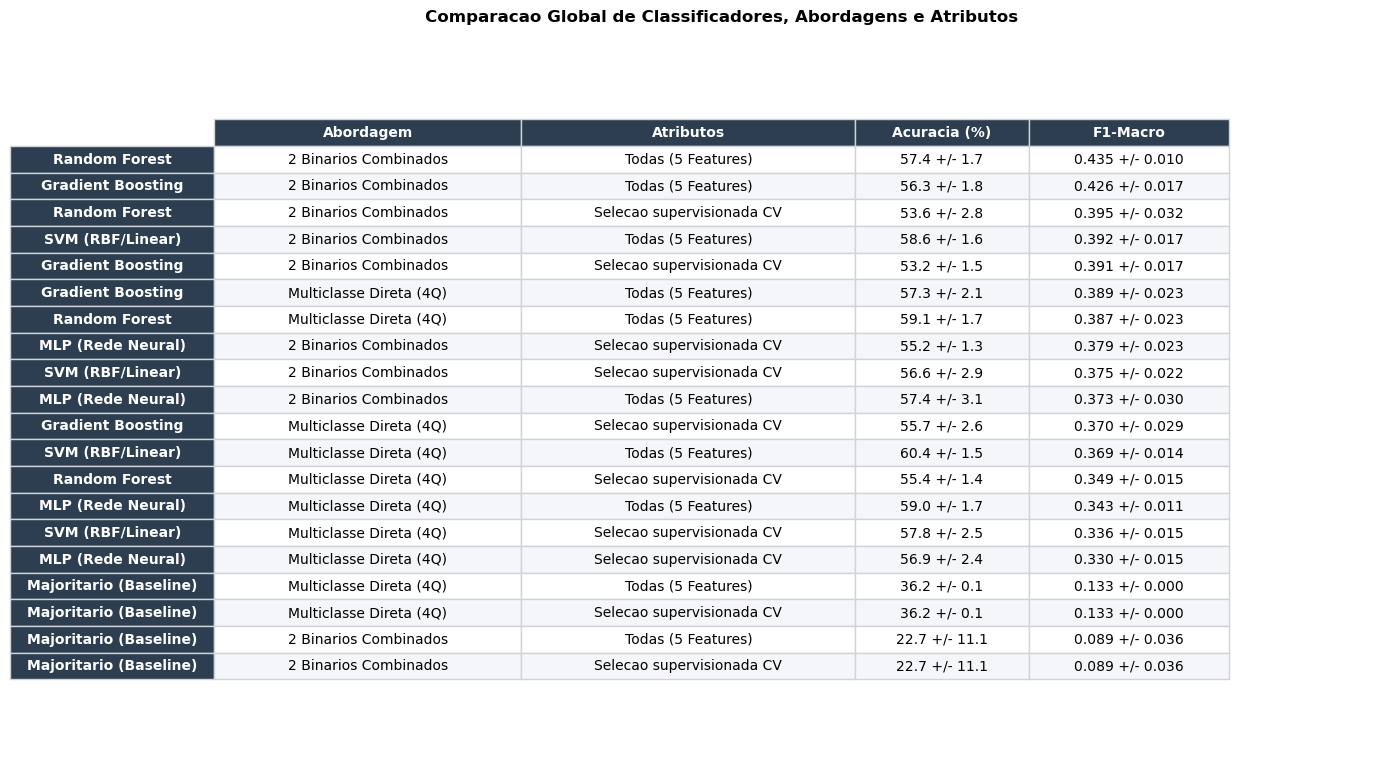

Tabela salva em: Images/tabela_comparativa_global.png


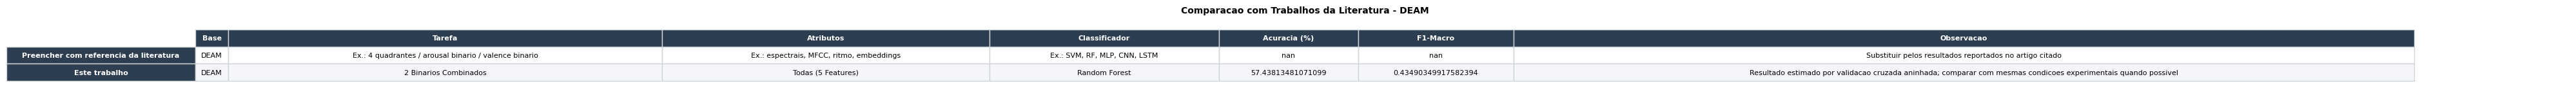

Tabela salva em: Images/tabela_comparacao_literatura_deam.png


In [20]:
# 13.1 Consolidacao da tabela comparativa geral e estrutura para literatura

df_global_summary = pd.concat([df_multi, df_bin], ignore_index=True)
df_global_summary = df_global_summary.sort_values(['F1_raw', 'Acc_raw'], ascending=False).reset_index(drop=True)

print('=== TABELA DE DESEMPENHO COMPARATIVO GLOBAL ===')
display(df_global_summary[['Modelo', 'Abordagem', 'Atributos', 'Acuracia (%)', 'F1-Macro', 'Precisao', 'Recall']])

benchmark_path = 'literatura_deam_benchmark.csv'
benchmark_columns = ['Trabalho', 'Base', 'Tarefa', 'Atributos', 'Classificador', 'Acuracia (%)', 'F1-Macro', 'Observacao']
if os.path.exists(benchmark_path):
    df_literatura = pd.read_csv(benchmark_path)
else:
    df_literatura = pd.DataFrame([
        {
            'Trabalho': 'Preencher com referencia da literatura',
            'Base': 'DEAM',
            'Tarefa': 'Ex.: 4 quadrantes / arousal binario / valence binario',
            'Atributos': 'Ex.: espectrais, MFCC, ritmo, embeddings',
            'Classificador': 'Ex.: SVM, RF, MLP, CNN, LSTM',
            'Acuracia (%)': np.nan,
            'F1-Macro': np.nan,
            'Observacao': 'Resultados reportados no estudo de referência'
        }
    ], columns=benchmark_columns)
    df_literatura.to_csv(benchmark_path, index=False)

melhor_resultado = df_global_summary.iloc[0]
df_resultado_proposto = pd.DataFrame([{
    'Trabalho': 'Este trabalho',
    'Base': 'DEAM',
    'Tarefa': melhor_resultado['Abordagem'],
    'Atributos': melhor_resultado['Atributos'],
    'Classificador': melhor_resultado['Modelo'],
    'Acuracia (%)': melhor_resultado['Acc_raw'],
    'F1-Macro': melhor_resultado['F1_raw'],
    'Observacao': 'Resultado estimado por validacao cruzada aninhada; comparar com mesmas condicoes experimentais quando possivel'
}])

df_comparacao_literatura = pd.concat([df_literatura, df_resultado_proposto], ignore_index=True)
print('\n=== COMPARACAO COM TRABALHOS QUE USAM A BASE DEAM ===')
display(df_comparacao_literatura)

if SAVE_FIGURES:
    salvar_tabela_como_imagem(
        df_global_summary[['Modelo', 'Abordagem', 'Atributos', 'Acuracia (%)', 'F1-Macro']].set_index('Modelo'),
        f'{FIG_DIR}/tabela_comparativa_global.png',
        titulo='Comparacao Global de Classificadores, Abordagens e Atributos'
    )
    salvar_tabela_como_imagem(
        df_comparacao_literatura.set_index('Trabalho'),
        f'{FIG_DIR}/tabela_comparacao_literatura_deam.png',
        titulo='Comparacao com Trabalhos da Literatura - DEAM',
        fontsize=8
    )


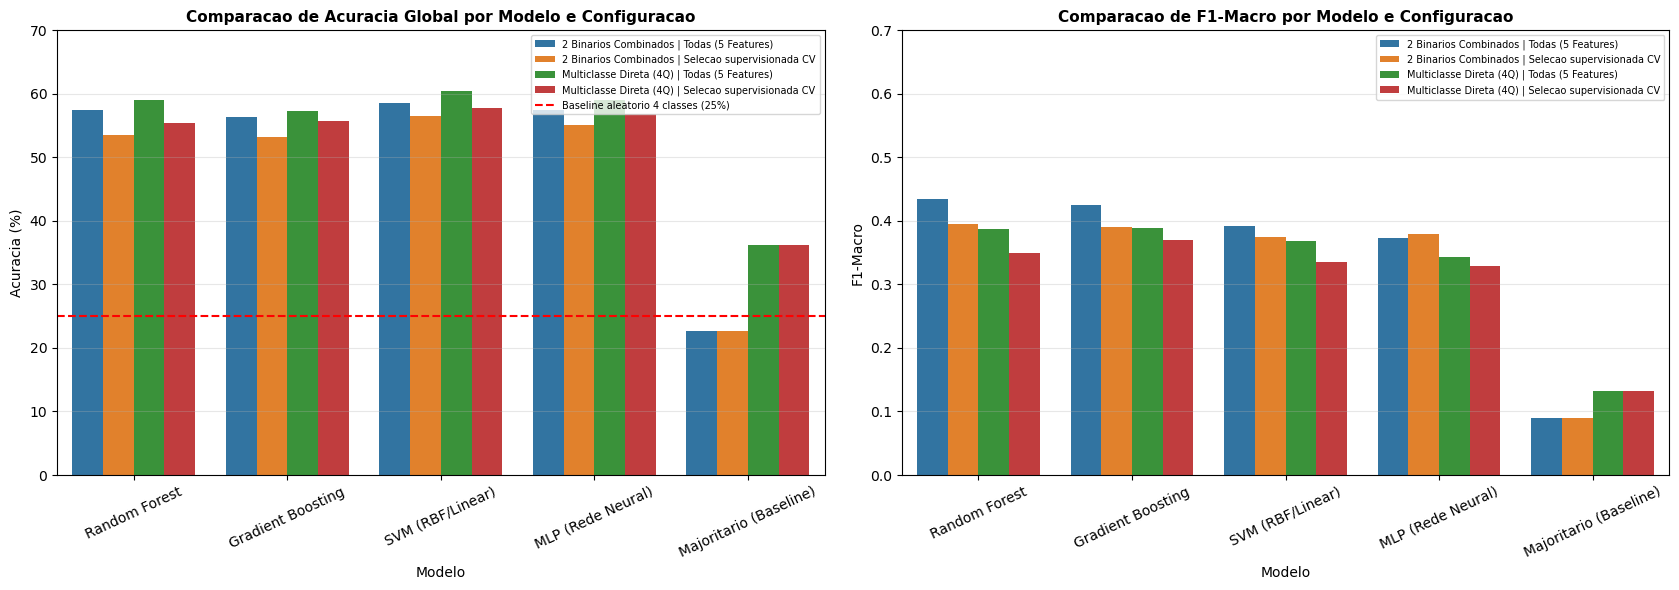

In [21]:
# 13.2 Grafico comparativo de desempenho

plot_df = df_global_summary.copy()
plot_df['Configuracao'] = plot_df['Abordagem'] + ' | ' + plot_df['Atributos']

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

sns.barplot(
    data=plot_df, x='Modelo', y='Acc_raw', hue='Configuracao', ax=axes[0]
)
axes[0].axhline(25.0, color='red', linestyle='--', label='Baseline aleatorio 4 classes (25%)')
axes[0].set_title('Comparacao de Acuracia Global por Modelo e Configuracao', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Acuracia (%)', fontsize=10)
axes[0].set_xlabel('Modelo', fontsize=10)
axes[0].set_ylim([0, max(70, plot_df['Acc_raw'].max() + 8)])
axes[0].tick_params(axis='x', rotation=25)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].legend(fontsize=7, loc='best')

sns.barplot(
    data=plot_df, x='Modelo', y='F1_raw', hue='Configuracao', ax=axes[1]
)
axes[1].set_title('Comparacao de F1-Macro por Modelo e Configuracao', fontsize=11, fontweight='bold')
axes[1].set_ylabel('F1-Macro', fontsize=10)
axes[1].set_xlabel('Modelo', fontsize=10)
axes[1].set_ylim([0, max(0.7, plot_df['F1_raw'].max() + 0.08)])
axes[1].tick_params(axis='x', rotation=25)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].legend(fontsize=7, loc='best')

plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(f'{FIG_DIR}/grafico_comparativo_modelos.png', dpi=200, bbox_inches='tight')
plt.show()


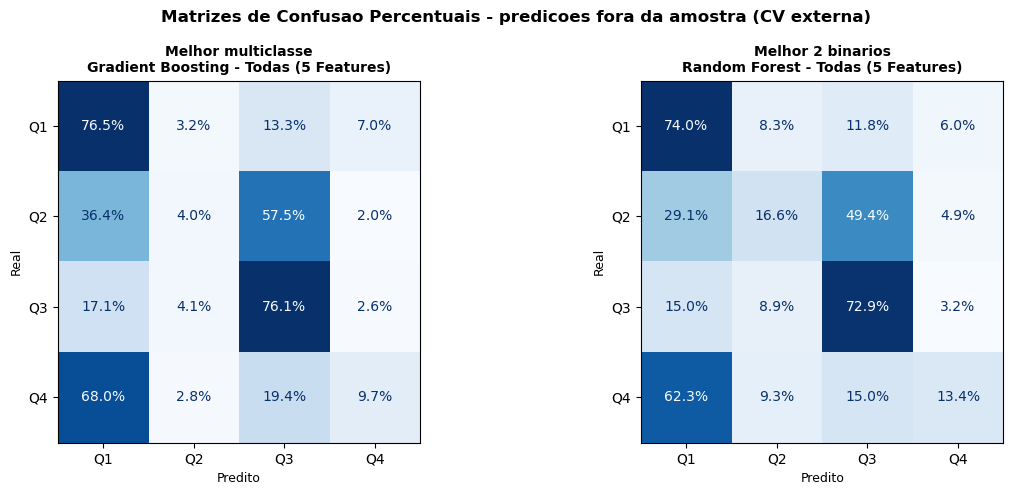

Melhor configuracao multiclasse:


,Modelo,Abordagem,Atributos,Acuracia (%),F1-Macro,Precisao,Recall,Acc_raw,F1_raw,Best_Params_Final,Params_por_fold
2,Gradient Boosting,Multiclasse Direta (4Q),Todas (5 Features),57.3 +/- 2.1,0.389 +/- 0.023,0.408 +/- 0.045,0.416 +/- 0.020,57.272392,0.38922,"{'clf__learning_rate': 0.1, 'clf__max_depth': ...","[{'clf__learning_rate': 0.1, 'clf__max_depth':..."


Melhor configuracao por 2 binarios combinados:


,Modelo,Abordagem,Atributos,Acuracia Bin Arousal (%),Acuracia Bin Valence (%),Acuracia (%),F1-Macro,Precisao,Recall,Acc_raw,F1_raw,Params_Arousal_por_fold,Params_Valence_por_fold
1,Random Forest,2 Binarios Combinados,Todas (5 Features),78.1 +/- 2.6,67.6 +/- 1.3,57.4 +/- 1.7,0.435 +/- 0.010,0.454 +/- 0.012,0.442 +/- 0.010,57.438135,0.434903,"[{'clf__max_depth': 10, 'clf__min_samples_leaf...","[{'clf__max_depth': 10, 'clf__min_samples_leaf..."


In [22]:
# 13.3 Matrizes de confusao dos melhores classificadores por abordagem

best_multi_row = df_multi.sort_values(['F1_raw', 'Acc_raw'], ascending=False).iloc[0]
best_bin_row = df_bin.sort_values(['F1_raw', 'Acc_raw'], ascending=False).iloc[0]

confusion_specs = [
    ('Melhor multiclasse', best_multi_row, oof_multi[(best_multi_row['Modelo'], best_multi_row['Atributos'])]),
    ('Melhor 2 binarios', best_bin_row, oof_bin[(best_bin_row['Modelo'], best_bin_row['Atributos'])])
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (title_prefix, row, preds) in zip(axes, confusion_specs):
    cm = confusion_matrix(y_quad, preds, normalize='true') * 100
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', values_format='.1f', ax=ax, colorbar=False)
    for text_obj in disp.text_.ravel():
        text_obj.set_text(text_obj.get_text() + '%')
        text_obj.set_fontsize(10)
    ax.set_title(f'{title_prefix}\n{row["Modelo"]} - {row["Atributos"]}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predito', fontsize=9)
    ax.set_ylabel('Real', fontsize=9)

plt.suptitle('Matrizes de Confusao Percentuais - predicoes fora da amostra (CV externa)', fontsize=12, fontweight='bold')
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(f'{FIG_DIR}/matrizes_confusao_melhores_abordagens.png', dpi=200, bbox_inches='tight')
plt.show()

print('Melhor configuracao multiclasse:')
display(best_multi_row.to_frame().T)
print('Melhor configuracao por 2 binarios combinados:')
display(best_bin_row.to_frame().T)
